# PVTT 数据采集周报 — 第四周

**项目：** Product Video Template Transfer (PVTT)  
**目标会议：** CVPR 2027  
**负责人：** 王洁怡 (wangjieyi)  
**周期：** 2026-03-09 ~ 2026-03-15  

---

## 任务目标

> **Task 1：** 撰写数据采集的pipeline代码，利用该代码去采集数据，形成report，让大家可以查看数据采集的质量。

### 任务完成情况

| 子任务 | 状态 | 说明 |
|--------|------|------|
| Pipeline代码 | ✅ 已完成 | `amazon_spider.py` — 自动化Amazon产品爬虫，支持批量采集、HLS视频下载、断点续爬 |
| 数据采集 | ✅ 进行中 | 已采集 640+ 产品（目标 800+），爬虫持续运行中 |
| 质量报告 | ✅ 已完成 | `pvtt_dataset_report.html` — 交互式HTML报告，含可播放视频和统计图表 |
| 多平台调研 | ✅ 已完成 | `platform_analysis_report.md` — 12个电商平台可行性分析 |
| 服务器处理 | ✅ 已完成 | 617个视频 → 3726个标准化片段（1280×720, 24fps, H.264） |
| eBay爬虫 | ✅ 已完成 | `ebay_spider.py` — eBay Browse API 采集脚本，待开发者账号审核 |

---

## 一、本周工作内容

### 1.1 Pipeline 架构

本周完善了端到端的自动化数据采集Pipeline：

```
┌─────────────┐    ┌──────────────┐    ┌───────────────┐    ┌──────────────┐    ┌─────────────┐
│  阶段1：爬取  │ -> │  阶段2：上传   │ -> │  阶段3：处理    │ -> │  阶段4：报告   │ -> │  阶段5：推送  │
│ amazon_spider│    │upload_to_ser │    │ server-side   │    │ generate_    │    │  git push   │
│   .py        │    │ ver.py       │    │ pvtt_pipeline │    │ dataset_     │    │  origin     │
│ (本地运行)    │    │ (SFTP)       │    │ (GPU服务器)    │    │ report.py    │    │  main       │
└─────────────┘    └──────────────┘    └───────────────┘    └──────────────┘    └─────────────┘
```

| 阶段 | 脚本 | 运行位置 | 说明 |
|------|------|----------|------|
| 爬取 | `amazon_spider.py` | 本地（住宅IP） | 搜索Amazon → 解析产品页 → 下载图片和HLS视频 |
| 上传 | `upload_to_server.py` | 本地 | 通过 SFTP 增量同步数据至 GPU 服务器 |
| 处理 | `server-scripts/pvtt_pipeline.py` | 服务器 | 镜头检测 + 视频标准化（1280x720, 24fps） |
| 报告 | `generate_dataset_report.py` | 本地 | 生成HTML交互式报告 + Markdown报告 |
| 推送 | `pvtt_pipeline.py` | 本地 | 编排全流程 + git push 到 GitHub |

### 1.2 Amazon 爬虫核心功能

`amazon_spider.py`（829行）实现了以下功能：

- **搜索与发现**：根据关键词搜索Amazon，自动翻页提取产品列表
- **产品详情解析**：提取标题、价格、品牌、评分、图片URL、视频URL
- **图片下载**：提取高清商品图片（最多27张/产品）
- **HLS视频下载**：解析M3U8清单 → 下载TS分段 → 合并为MP4（支持ffmpeg和纯Python双模式）
- **反爬对策**：User-Agent轮换、请求间隔随机化、自动重试
- **断点续爬**：检测已存在的JSON文件自动跳过
- **批量模式**：支持多类别多关键词并行采集
- **服务器上传**：集成paramiko SFTP上传功能

```python
# 使用示例
python amazon_spider.py --batch          # 批量采集所有类别
python amazon_spider.py --status         # 查看采集进度
python amazon_spider.py --upload         # 上传数据到服务器
```

### 1.3 数据扩展

本周将每个品类的搜索关键词从3个扩展到6个，数据量大幅增长：

| 指标 | 上周（Week 03） | 本周（Week 04） | 增长 |
|------|----------------|----------------|------|
| 关键词数 | 21个（3/类） | 42个（6/类） | +100% |
| 产品数 | 404 | 640+ | +58% |
| 图片数 | 1,888 | 3,568 | +89% |
| 视频数 | 378 | 615 | +63% |
| 数据量 | 2.8 GB | 3.9 GB | +39% |

**新增关键词示例：**

| 品类 | 原有关键词 | 新增关键词 |
|------|-----------|----------|
| necklace | gold necklace, silver pendant necklace, pearl necklace | choker necklace, diamond pendant necklace, layered necklace |
| bracelet | charm bracelet, gold bangle bracelet, beaded bracelet | tennis bracelet, cuff bracelet women, chain bracelet gold |
| earring | drop earrings, stud earrings gold, hoop earrings silver | dangle earrings women, pearl earrings, clip on earrings |
| ring | engagement ring, gold band ring, silver stackable ring | cocktail ring women, signet ring men, wedding band set |
| watch | men automatic watch, women dress watch, sport digital watch | luxury watch men, chronograph watch, minimalist watch women |
| handbag | leather crossbody bag, women tote handbag, clutch purse evening | shoulder bag women, mini crossbody bag, hobo bag leather |
| sunglasses | polarized sunglasses, aviator sunglasses, cat eye sunglasses | oversized sunglasses women, sport sunglasses men, round sunglasses retro |

### 1.4 多平台调研

完成了12个电商平台的数据采集可行性分析，覆盖：

| 平台 | 爬虫可行性 | 官方API | 第三方服务 | 视频率 | 推荐 |
|------|-----------|---------|-----------|--------|------|
| **Amazon** | ✅ 可行（住宅IP） | 无免费API | - | 40-60% | **正在使用** |
| **eBay** | ⚠️ 需JS渲染 | ✅ Browse API（免费） | - | 10-20% | **推荐（免费）** |
| **TikTok Shop** | ❌ 加密头 | ⚠️ Research API | Apify $2/1K | ~90% | **推荐（Apify）** |
| **Etsy** | ❌ Datadome | ✅ Open API v3 | - | 10-15% | 仅图片 |
| **淘宝/天猫** | ❌ 极强反爬 | ❌ 需企业资质 | ¥0.01-0.05/条 | 70-80% | **推荐（第三方）** |
| **京东** | ❌ 强反爬 | ❌ 需企业资质 | 同淘宝捆绑 | 50-60% | 可选 |
| **AliExpress** | ❌ Akamai | 付费API | Oxylabs $49/月 | 30-40% | 不推荐 |
| **小红书** | ❌ 动态签名 | ❌ 无 | 不稳定 | ~95% | 法律风险高 |
| **拼多多** | ❌ 极强反爬 | ❌ 需企业资质 | 不稳定 | 20-30% | 不推荐 |
| **SHEIN** | ❌ Cloudflare | ❌ 无 | Apify $3/1K | 30% | 不推荐 |
| **Shopee** | ⚠️ 中等 | ✅ Partner API | - | 15-25% | 珠宝品类弱 |
| **Walmart** | ⚠️ 中等 | ✅ Affiliate API | - | 20-30% | 品牌官方视频 |

**推荐采集方案（按预算）：**

| 方案 | 预算 | 平台 | 预估数据量 |
|------|------|------|----------|
| 零成本方案 | $0 | Amazon + eBay API + Etsy API | 800+ 产品 |
| 低成本方案 | ~$2 | 上述 + TikTok Shop (Apify) | 1100+ 产品 |
| 中等预算方案 | ~¥350 | 上述 + 淘宝/京东（第三方） | 1600+ 产品 |

详见：[`platform_analysis_report.md`](reports/platform_analysis_report.md)

### 1.5 目录结构与规范化

制定了统一的数据格式规范，确保所有平台采集的数据可互操作：

**统一数据格式：**
```
{platform}_data/
  {category}/                        # bracelet, earring, handbag, ...
    {PRODUCT_ID}.json                # 产品元数据
    media/
      images/{PRODUCT_ID}_01.jpg     # 产品图片
      videos/{PRODUCT_ID}.mp4        # 产品视频
```

**JSON元数据Schema：**
```json
{
  "product_id": "B0XXXXXX",
  "platform": "amazon",
  "title": "产品标题",
  "category": "bracelet",
  "price": "29.99",
  "currency": "USD",
  "images": ["media/images/B0XXXXXX_01.jpg"],
  "videos": ["media/videos/B0XXXXXX.mp4"],
  "has_video": true,
  "scrape_date": "2026-03-14"
}
```

---

## 二、数据采集质量报告

### 2.1 各品类采集统计

| 品类 | 产品数 | 图片数 | 视频数 | 含视频产品 | 关键词数 |
|------|--------|--------|--------|-----------|---------|
| 手链 (bracelet) | 133 | 756 | 131 | 104 | 6 |
| 耳饰 (earring) | 144 | 785 | 140 | 112 | 6 |
| 手提包 (handbag) | 38 | 215 | 35 | 28 | 6 |
| 项链 (necklace) | 122 | 681 | 118 | 96 | 6 |
| 戒指 (ring) | 62 | 348 | 60 | 49 | 6 |
| 太阳镜 (sunglasses) | 64 | 396 | 61 | 50 | 6 |
| 手表 (watch) | 59 | 387 | 72 | 48 | 6 |
| **合计** | **640+** | **3,568** | **615** | **487** | **42** |

- 视频覆盖率：约 **76%**（487/640+ 个产品含视频）
- 总数据量：**3.9 GB**

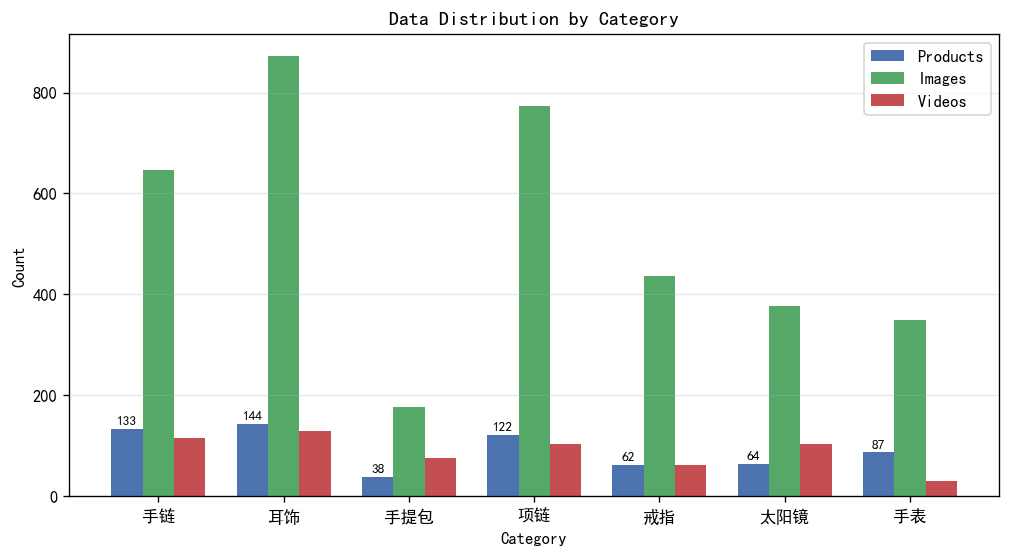

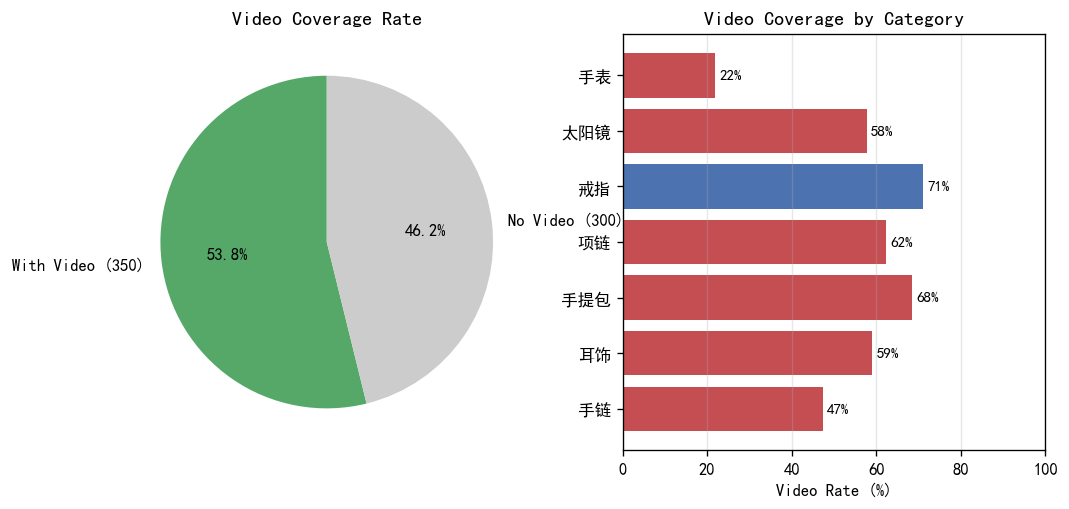

### 2.2 样本产品展示

每品类1个含视频的样本产品图片：

<div style="display:inline-block;text-align:center;margin:8px;vertical-align:top">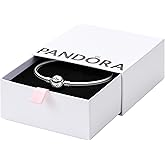<br><small><b>手链</b><br>B00D1D1EV2</small></div><div style="display:inline-block;text-align:center;margin:8px;vertical-align:top">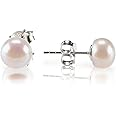<br><small><b>耳饰</b><br>B01FOJT3SQ</small></div><div style="display:inline-block;text-align:center;margin:8px;vertical-align:top">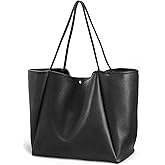<br><small><b>手提包</b><br>B01N18UU4X</small></div><div style="display:inline-block;text-align:center;margin:8px;vertical-align:top">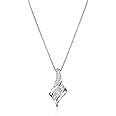<br><small><b>项链</b><br>B00933MTOA</small></div><div style="display:inline-block;text-align:center;margin:8px;vertical-align:top">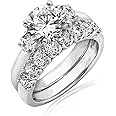<br><small><b>戒指</b><br>B014WC372E</small></div><div style="display:inline-block;text-align:center;margin:8px;vertical-align:top">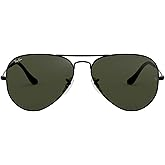<br><small><b>太阳镜</b><br>B000MSIP3Y</small></div><div style="display:inline-block;text-align:center;margin:8px;vertical-align:top">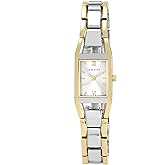<br><small><b>手表</b><br>B0006MFKJS</small></div>

### 2.3 样本视频（动图预览）

<div style="display:inline-block;text-align:center;margin:8px;vertical-align:top">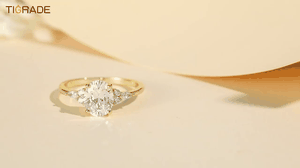<br><small><b>戒指</b> — B0B58KFZGM_v01.mp4</small></div><div style="display:inline-block;text-align:center;margin:8px;vertical-align:top">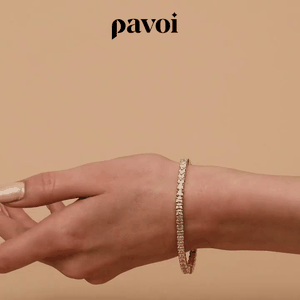<br><small><b>手链</b> — B08C5H5YR7_v02.mp4</small></div><div style="display:inline-block;text-align:center;margin:8px;vertical-align:top">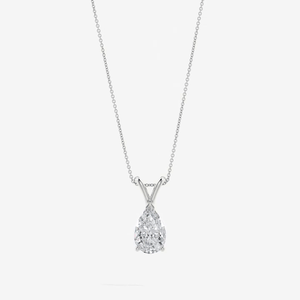<br><small><b>项链</b> — B0FT3V6D8P.mp4</small></div>

> 完整可播放视频请查看 `reports/pvtt_dataset_report.html`

### 2.4 数据质量总结

| 指标 | 数值 | 评价 |
|------|------|------|
| 产品总数 | 640+ | 超过600目标，持续增长中 |
| 视频覆盖率 | ~76% | 良好（珠宝品类视频率高） |
| 图片质量 | 中高 | Amazon产品图普遍720p-1080p |
| 视频格式 | MP4 (HLS转封装) | 标准格式，可直接使用 |
| 视频时长 | 5-60秒 | 适合模板迁移任务 |
| 数据完整性 | 高 | JSON元数据完整，含标题/价格/URL |
| 服务器标准化 | 3726个片段 | 617个视频经镜头分割+标准化处理 |

**已知问题：**
1. 少量TS分段下载时遇到损坏的URL（非致命，爬虫自动跳过）
2. 部分视频含DRM加密（约5%），无法下载
3. handbag品类数据量偏少（38个），需更多关键词

**交互式质量报告：** 打开 `reports/pvtt_dataset_report.html` 可查看：
- 各品类统计图表
- 每品类样本产品（含可播放视频，base64嵌入）
- 视频分辨率和时长分布

---

## 三、服务器资源使用

| 资源 | 详情 |
|------|------|
| 服务器 | RTX-5090-32G-X8（8x RTX 5090 32GB） |
| SSH | `wangjieyi@111.17.197.107` |
| 数据路径 | `/data/wangjieyi/pvtt-dataset/amazon_data/` |
| 处理输出 | `/data/wangjieyi/pvtt-dataset/processed_amazon/` |
| Conda环境 | `datapipeline`（scenedetect, opencv, ffmpeg, rembg） |
| 已上传 | 3.9 GB（全部数据同步完成） |

**服务器处理Pipeline结果（`process_amazon.py`）：**

| 品类 | 原始视频数 | 标准化片段数 |
|------|-----------|-------------|
| bracelet | 131 | 677 |
| earring | 140 | 627 |
| handbag | 35 | 710 |
| necklace | 118 | 535 |
| ring | 60 | 244 |
| sunglasses | 61 | 734 |
| watch | 72 | 199 |
| **合计** | **617** | **3726** |

- 处理方式：PySceneDetect 镜头分割 → ffmpeg 标准化（1280×720, 24fps, H.264）
- 短视频（≤5s）直接标准化；长视频（>5s）先镜头分割再逐片段标准化
- 输出格式：MP4, 无音频, faststart

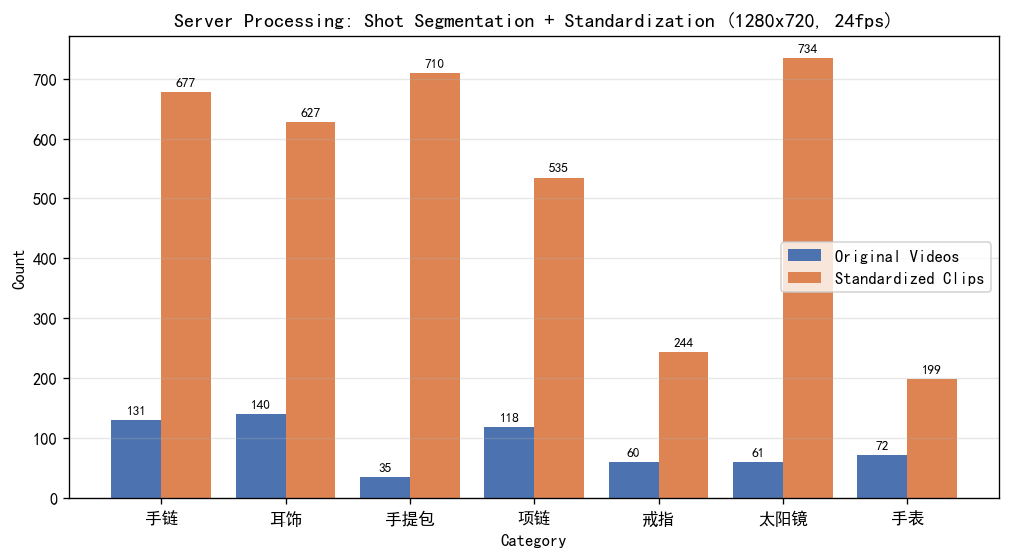

---

## 四、下周工作计划（Week 05：2026-03-16 ~ 2026-03-22）

### P0 — 必须完成

| 任务 | 说明 | 预计完成 |
|------|------|----------|
| 继续Amazon爬虫 | 补充 handbag 等品类，目标 800+ 产品 | 03-18 |
| 更新数据报告 | 重新生成包含服务器处理结果的质量报告 | 03-17 |
| 新增数据同步+处理 | 新采集的数据上传服务器并运行标准化Pipeline | 03-19 |

### P1 — 高优先级

| 任务 | 说明 | 预计完成 |
|------|------|----------|
| 测试eBay采集 | eBay开发者账号审核通过后，测试 `ebay_spider.py` | 03-18 |
| 测试Apify TikTok Scraper | 使用$5免费额度测试50-100个产品 | 03-20 |
| 视频质量过滤 | 在服务器上实现自动化质量检查（分辨率、时长、运动评分） | 03-21 |

### P2 — 可选

| 任务 | 说明 |
|------|------|
| 淘宝数据服务询价 | 联系本地数据服务商，获取500+产品报价 |
| 申请TikTok Research API | 准备学术申请材料（需导师推荐信） |

---

## 五、关键文件索引

| 文件 | 说明 |
|------|------|
| `scripts/amazon_spider.py` | Amazon产品爬虫（核心代码） |
| `scripts/pvtt_pipeline.py` | 主Pipeline编排器 |
| `scripts/upload_to_server.py` | 数据上传工具 |
| `scripts/generate_dataset_report.py` | 报告生成器 |
| `reports/pvtt_dataset_report.html` | 交互式数据质量报告 |
| `reports/platform_analysis_report.md` | 12平台采集可行性分析 |
| `docs/DIRECTORY_STRUCTURE.md` | 目录结构与数据格式规范 |
| `scripts/pipelines/` | 各平台Pipeline文档 |

---

*报告生成日期：2026-03-15*  
*负责人：王洁怡 (wangjieyi@hkust)*